In [17]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import sys
import matplotlib as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, when
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.stat import Correlation
from pyspark.ml.linalg import DenseMatrix
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import StringIndexer


#Init Spark
spark = SparkSession.builder.appName("Corr_and_PCA_on_Cleaned").getOrCreate()

df = spark.read.option("header", True)\
    .option("delimiter", ",")\
    .option("encoding", "utf-8")\
    .option("multiLine", True)\
    .option("quote", '"')\
    .option("escape", '"')\
    .csv("hdfs://localhost:9000/twitter/twitter_cleaned")

indexer = StringIndexer(inputCol="account_type", outputCol="account_type_indexed")
df = indexer.fit(df).transform(df)

classes = df.select("account_type_indexed").distinct().rdd.flatMap(lambda x: x).collect()

# Filtrage des classes
class_0_df = df.filter(col("account_type_indexed") == classes[0])
class_1_df = df.filter(col("account_type_indexed") == classes[1])

count_0 = class_0_df.count()
count_1 = class_1_df.count()

# Déterminer la minorité
minor_df, major_df = (class_0_df, class_1_df) if count_0 <= count_1 else (class_1_df, class_0_df)
minor_count = minor_df.count()

# Sous-échantillonnage de la majorité
major_sampled_df = major_df.sample(False, float(minor_count) / major_df.count(), seed=42)

#équilibrage
df = minor_df.union(major_sampled_df)

df.groupBy("account_type_indexed").count().show()


#nulls
print("=== Nombre de valeurs nulles par colonne ===")
null_counts = df.select([
    _sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

print("=== Exemples de lignes contenant des nulls ===")
df.filter(
    sum(when(col(c).isNull(), 1).otherwise(0) for c in df.columns) > 0
).show(10, truncate=False)

cols = [
   "default_profile",
    "default_profile_image",
    "has_description",
    "favourites_count",
    "followers_count",
    "friends_count",
    "geo_enabled",
    "statuses_count",
    "verified",
    "account_age_days",
]
for c in cols:
    df = df.withColumn(c, col(c).cast("double"))

#Calcul des médianes et imputation
medians = {
    c: df.approxQuantile(c, [0.5], 0.01)[0] if df.filter(col(c).isNotNull()).count() > 0 else 0.0
    for c in cols
}
df = df.na.fill(medians)

#Filtrer celles à variance nulle
stats = df.select(*cols).summary("stddev").collect()[0].asDict()
to_keep = [c for c in cols if float(stats[c]) != 0.0]
if not to_keep:
    print("Aucune colonne à variance non nulle → rien à faire.")
    spark.stop()
    sys.exit(1)

#Vectorisation
assembler = VectorAssembler(inputCols=to_keep, outputCol="features")
df_vec = assembler.transform(df)

n = df_vec.count()
if n == 0:
    print("Aucune ligne valide → vérifiez vos données.")
    spark.stop()
    sys.exit(1)
print(f"Lignes valides : {n}, Colonnes utilisées : {to_keep}")

#Matrice de corrélation Pearson
corr_struct = Correlation.corr(df_vec, "features", method="pearson").head()[0]
dm = DenseMatrix(corr_struct.numRows,
                 corr_struct.numCols,
                 corr_struct.toArray().flatten().tolist())
print("=== Matrice de corrélation Pearson ===")
print(dm)

#Standardisation
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)
scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec)

#PCA (3 composants)
pca = PCA(k=3, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

#Variance expliquée
print("\n=== Variance expliquée par composante ===")
for i, v in enumerate(pca_model.explainedVariance.toArray(), start=1):
    print(f"PC{i} : {v:.4f}")

df_out = df_pca.withColumn("pca_array", vector_to_array("pca_features"))

df_out.select(
    col("pca_array")[0].alias("PC1"),
    col("pca_array")[1].alias("PC2"),
    col("pca_array")[2].alias("PC3")
).show(100, truncate=False)



+--------------------+-----+
|account_type_indexed|count|
+--------------------+-----+
|                 1.0|12425|
|                 0.0|12503|
+--------------------+-----+

Lignes valides : 24928, Colonnes utilisées : ['default_profile', 'default_profile_image', 'has_description', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'statuses_count', 'verified', 'account_age_days']
=== Matrice de corrélation Pearson ===
DenseMatrix([[ 1.        ,  0.1195382 , -0.23810404, -0.10739333, -0.09738116,
              -0.06086672, -0.29635665, -0.1349718 , -0.26814932, -0.44335965],
             [ 0.1195382 ,  1.        , -0.21961367, -0.03305083, -0.01885399,
              -0.01279522, -0.09728167, -0.02608852, -0.05933287, -0.04442644],
             [-0.23810404, -0.21961367,  1.        ,  0.1036732 ,  0.04729554,
               0.04105156,  0.16042448,  0.10376983,  0.19421632,  0.02836049],
             [-0.10739333, -0.03305083,  0.1036732 ,  1.        , -0.01638595,


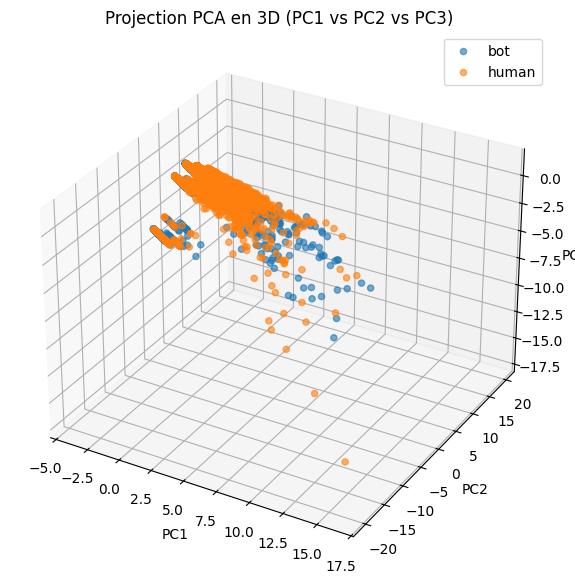

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

df_plot = df_out.select(
    col("pca_array")[0].alias("PC1"),
    col("pca_array")[1].alias("PC2"),
    col("pca_array")[2].alias("PC3"),
    "account_type"
)
df_plot_pd = df_plot.toPandas()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in df_plot_pd["account_type"].unique():
    subset = df_plot_pd[df_plot_pd["account_type"] == label]
    ax.scatter(
        subset["PC1"], subset["PC2"], subset["PC3"],
        label=label, alpha=0.6
    )

ax.set_title("Projection PCA en 3D (PC1 vs PC2 vs PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()


In [23]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

indexer = StringIndexer(inputCol="account_type", outputCol="label")
indexer_model = indexer.fit(df_pca)
df_indexed = indexer_model.transform(df_pca)

df_model = df_indexed.select("label", "pca_features")

train_data, test_data = df_model.randomSplit([0.8, 0.2])

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="pca_features",
    numTrees=200,
    maxDepth=6
)

rf_model = rf.fit(train_data)

predictions = rf_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Précision de la Random Forest : {accuracy:.4f}")

predictions.select("label", "prediction", "probability").show(2000, truncate=False)


25/07/25 14:36:36 WARN DAGScheduler: Broadcasting large task binary with size 1777.3 KiB
25/07/25 14:36:37 WARN DAGScheduler: Broadcasting large task binary with size 1449.1 KiB


Précision de la Random Forest : 0.7705


25/07/25 14:36:38 WARN DAGScheduler: Broadcasting large task binary with size 1441.0 KiB


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.15903488170544683,0.8409651182945531]|
|1.0  |1.0       |[0.1588950215655867,0.8411049784344133] |
|1.0  |1.0       |[0.1588950215655867,0.8411049784344133] |
|1.0  |1.0       |[0.1588950215655867,0.

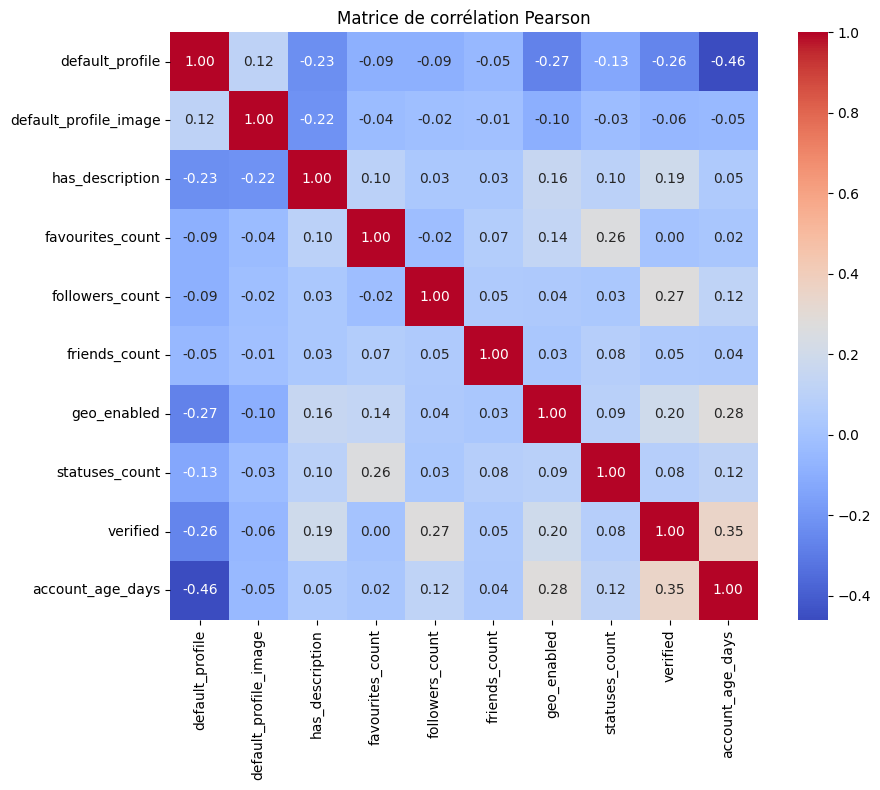

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_array = np.array(dm.values).reshape(dm.numRows, dm.numCols)

#Affichage avec seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_array,
            xticklabels=to_keep,
            yticklabels=to_keep,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            square=True,
            cbar=True)

plt.title("Matrice de corrélation Pearson")
plt.tight_layout()
plt.show()


In [22]:
# Affichage des composantes principales (vecteurs propres)
components = pca_model.pc.toArray()  #(nb_colonnes, k)

features_used = assembler.getInputCols()
import pandas as pd

df_components = pd.DataFrame(components,
                              index=features_used,
                              columns=["PC1", "PC2", "PC3"])

print("\n=== Poids des variables dans chaque composante principale ===")
print(df_components)



=== Poids des variables dans chaque composante principale ===
                            PC1       PC2       PC3
default_profile       -0.469092  0.057025 -0.057450
default_profile_image -0.174858 -0.203486 -0.640913
has_description        0.290146  0.265300  0.485441
favourites_count       0.191046  0.583620 -0.275478
followers_count        0.219615 -0.365607 -0.161055
friends_count          0.123272  0.177844 -0.314997
geo_enabled            0.392502  0.019347  0.033325
statuses_count         0.225246  0.454001 -0.346066
verified               0.415720 -0.307921 -0.042224
account_age_days       0.433187 -0.278822 -0.163011


In [15]:
raw_input = {
    "default_profile": 0.0,
    "default_profile_image": 0.0,
    "has_description": 0.0,
    "favourites_count": 50,
    "followers_count": 160,
    "friends_count": 20,
    "geo_enabled": 1.0,
    "statuses_count": 1,
    "verified": 1.0,
    "account_age_days": 1500
}
from pyspark.sql import Row
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import IndexToString

raw_df = spark.createDataFrame([Row(**raw_input)])

assembler = VectorAssembler(
    inputCols=[
        "default_profile",
        "default_profile_image",
        "has_description",
        "favourites_count",
        "followers_count",
        
        "friends_count",
        "geo_enabled",
        "statuses_count",
        "verified",
        "account_age_days"
    ],
    outputCol="features"
)
raw_vectorized = assembler.transform(raw_df)

#Standardisation
raw_scaled = scaler_model.transform(raw_vectorized)

#PCA
raw_pca = pca_model.transform(raw_scaled)

#rf
prediction_result = rf_model.transform(raw_pca)

converter = IndexToString(inputCol="prediction", outputCol="predicted_label", labels=indexer_model.labels)
prediction_result_labeled = converter.transform(prediction_result)
prediction_result_labeled.select("prediction", "predicted_label", "probability").show(truncate=False)


25/07/25 14:31:37 WARN DAGScheduler: Broadcasting large task binary with size 1416.9 KiB
25/07/25 14:31:37 WARN DAGScheduler: Broadcasting large task binary with size 1416.9 KiB


+----------+---------------+----------------------------------------+
|prediction|predicted_label|probability                             |
+----------+---------------+----------------------------------------+
|0.0       |human          |[0.8641556672796736,0.13584433272032645]|
+----------+---------------+----------------------------------------+



In [4]:
test_data.groupBy("label").count().show()
train_data.groupBy("label").count().show()


+-----+-----+
|label|count|
+-----+-----+
|  1.0| 2491|
|  0.0| 2462|
+-----+-----+

+-----+-----+
|label|count|
+-----+-----+
|  1.0| 9934|
|  0.0|10041|
+-----+-----+

